# **DLO-JZ Optimisation de l'apprentissage - Jour 2**
<img src="./images/optimisation.png" style="float: left; margin-right: 1em;"/>

<div class="alert alert-block alert-success">
    
## Objet du notebook

Le but de ce *notebook* est d'optimiser un code d'apprentissage d'un modèle *Resnet-50* sur *Imagenet* pour Jean Zay en implémentant :
* **TP2.1** : l'optimisation du *Dataloader*
* **TP2.2** : la distribution (*Data Parallelism*)
* **TP2.3** : le DDP et le problème des paramètres non utilisés


Les cellules dans ce *notebook* ne sont pas prévues pour être modifiées, sauf rares exceptions indiquées dans les commentaires. Les TP se feront en modifiant les codes `dlojz2_X.py`.

Les directives de modification seront marquées par l'étiquette suivante <div class="alert alert-block alert-warning">**TODO**</div>
Des solutions sont présentes dans le répertoire `solutions/`.

*Notebook rédigé par l'équipe assistance IA de l'IDRIS, mai 2026.*

</div>

### **Environnement de calcul**

Les fonctions *python* de gestion de queue SLURM développées par l'IDRIS et les fonctions dédiées à la formation DLO-JZ sont à importer.

Le module d'environnement pour les *jobs* et la taille des images sont fixés pour ce *notebook*.
<div class="alert alert-block alert-warning">
    
**TODO :** choisir un pseudonyme (maximum 5 caractères) pour vous différencier dans la queue SLURM pendant la formation.

</div>

In [1]:
from idr_pytools import display_slurm_queue, gpu_jobs_submitter, search_log
from dlojz_tools import controle_technique, compare, comm_profiler, turbo_profiler, BatchNorm_view, metric_compute_log
MODULE = 'arch/h100 pytorch-gpu/py3/2.8.0'
image_size = 224
account = 'sos@h100'
name = 'test_smi'   ## Pseudonyme à choisir
!mkdir -p checkpoints # Création d'un répertoire `checkpoints/` si cela n'a pas déjà été fait.

### **Gestion de la queue SLURM**

Pour afficher vos jobs dans la queue SLURM :

In [2]:
display_slurm_queue(name)


 Done!


**Remarque**: cette fonction sera utilisée plusieurs fois dans ce *notebook*. Elle permet d'afficher la queue de manière dynamique, rafraichie toutes les 5 secondes. Elle ne s'arrête que lorsque la queue est vide. Si vous désirez reprendre la main sur le *notebook*, il vous suffira d'arrêter manuellement la cellule avec le bouton *stop*. Cela n'a bien sûr aucun impact sur les *jobs* soumis.

Si vous voulez retirer TOUS vos *jobs* de la queue SLURM, décommenter et exécuter la cellule suivante :

In [3]:
#!scancel -u $USER

Si vous voulez retirer UN de vos *jobs* de la queue SLURM, décommenter, compléter et exécuter la cellule suivante :

In [4]:
#!scancel <jobid>

--------------

### Différence entre deux scripts

Pour comparer son code avec les solutions mises à disposition, la fonction suivante permet d'afficher une page HTML contenant un différentiel de fichiers texte.

In [5]:
s1 = "./dlojz2_2.py"
s2 = "./solutions/dlojz2_2.py"
compare(s1, s2)

Voir le résultat du différentiel de fichiers sur la page suivante (attention au spoil !) :

[compare.html](compare.html)

<div class="alert alert-block alert-success">
    
# TP2.1: Optimisation du DataLoader

Dans ce TP, on utilisera le script [dlojz2_1.py](./dlojz2_1.py) dans lequel le profiler PyTorch n'est pas implémenté. Ce script est identique à la solution du TP2_1.

Dans un premier temps, on va désactiver toutes les optimisations du DataLoader (**version sous-optimisée**). Ensuite,  nous pourrons observer l'impact de chacune des optimisations possibles en les réintégrant une par une.

## Découverte de turbo_profiler
Pour ce TP, nous avons implémenté un profiler maison léger `turbo_profiler` basé sur l'outil `Chronometer` pour visualiser le temps passé sur CPU (DataLoader) et sur GPU (le reste de l'itération). Ce profiler est moins précis mais cela nous permettra de désactiver le profiler PyTorch pour ne pas dégrader les performances et éviter de devoir ouvrir l'outil graphique TensorBoard à chaque fois pour visualiser les informations qui nous intéressent.

</div>

<div class="alert alert-block alert-info">

## Version sous-optimisée
<div class="alert alert-block alert-warning">
    
**TODO** : lancer l'exécution sur 1 GPU et 50 itérations (`--test-nsteps 50`) sans profiling pour passer un contrôle technique qui servira de référence. Cela va prendre quelques minutes (~5min), **vous pouvez passer à la suite sans attendre la fin de l'exécution**.

</div>
</div>

## Garage - Mise à niveau
On fixe la taille d'image pour ce TP et le batch size optimal d'après les expériences du Jour 1

In [6]:
image_size = 224
bs_optim = 512

### Soumission du job
<u>**Attention vous sollicitez les noeuds de calcul à ce moment-là**.</u>

Pour soumettre le job, veuillez basculer la cellule suivante du mode `Raw NBConvert` au mode `Code` (raccourci: touche `Y` avec la cellule sélectionnée)

In [7]:
command = f'./dlojz2_1.py -b {bs_optim} --image-size {image_size} --test --test-nsteps 16'
command += f' --num-workers 0 --no-persistent-workers --no-pin-memory --no-non-blocking'
n_gpu = 1
jobid = gpu_jobs_submitter(command, n_gpu, MODULE, name=name,
                           account=account, time_max='00:10:00', constraint="h100", qos="qos_gpu_h100-dev")
print(f'jobid = {jobid}')

batch job 0: 1 GPUs distributed on 1 nodes with 1 tasks / 1 gpus per node and 10 cpus per task
Submitted batch job 622047
jobid = ['622047']


Puis, rebasculer la cellule précédente en mode `Raw NBConvert`, afin d'eviter de relancer un job par erreur (raccourci: touche `R` avec la cellule sélectionnée).

In [8]:
display_slurm_queue(name)

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
            622047    gpu_p6 test_smi  ssos043  R       1:36      1 jzxh010

 Done!


<div class="alert alert-block alert-warning">

### **Quizz**

L'éxécution étant assez longue, un quizz vous attend : [Quizz TP2.1](https://www.deepmama.com/quizz/dlojz_quizz4.html)

</div>

In [9]:
controle_technique(jobid)

Train throughput: 209.28 images/second
GPU throughput: 2349.68 images/second
epoch time: 6123.61 seconds
-----------
training step time average (fwd/bkwd on GPU): 0.217902 sec (6.0%/94.5%) +/- 0.003953
loading step time average (IO + CPU to GPU transfer): 2.228604 sec +/- 0.120612


[Click here to display the log file](./slurm/log/test_smi@JZ_622047_1nodes_1tasks_2026-05-06_15.47.13.out)

<div class="alert alert-block alert-warning">
    
**TODO** : visualiser la sortie de `turbo_profiler`

</div>

>>> Turbo Profiler >>> Training complete in 71.171766 s


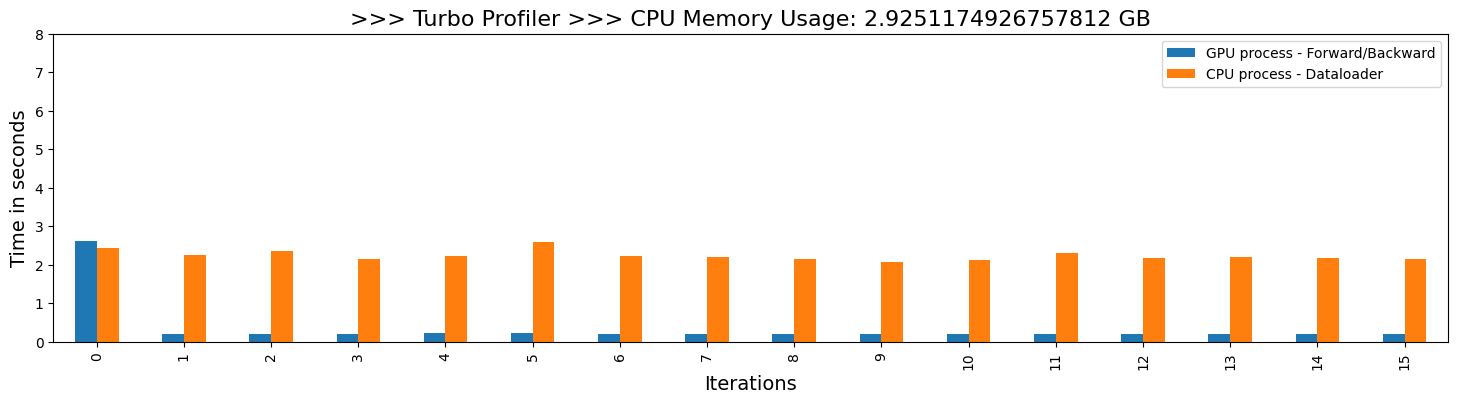

In [10]:
# call turbo_profiler
dataloader_trial = turbo_profiler(jobid,dataloader_info=True)

Via le turbo profiler, on va également récupérer et stocker les performances obtenues dans une DataFrame `dataloader_trials`
### Initialisation de la DataFrame :

In [11]:
import pandas as pd
dataloader_trials = pd.DataFrame({"jobid":pd.Series([],dtype=str),
                                  "num_workers":pd.Series([],dtype=int),
                                  "pin_memory":pd.Series([],dtype=str),
                                  "non_blocking":pd.Series([],dtype=str),
                                  "prefetch_factor":pd.Series([],dtype=int),
                                  "persistent_workers":pd.Series([],dtype=str),
                                  "drop_last":pd.Series([],dtype=str),
                                  "loading_time":pd.Series([],dtype=float),
                                  "1st_step_loading_time":pd.Series([],dtype=float),
                                  "CPU_memory_usage(GB)":pd.Series([],dtype=float)})

### Stockage du résultat précédent dans la *DataFrame* :

In [12]:
dataloader_trials = pd.concat([dataloader_trials,dataloader_trial], ignore_index=True)

### Visualisation du contenu de la *DataFrame* :

In [13]:
dataloader_trials.sort_values("loading_time")# trié par ordre croissant du LOADING_TIME

,jobid,num_workers,pin_memory,non_blocking,prefetch_factor,persistent_workers,drop_last,loading_time,1st_step_loading_time,CPU_memory_usage(GB)
0,622047,0,False,False,2,False,False,2.228604,2.447268,2.925117


<div class="alert alert-block alert-info">

## Exploration des paramètres d'optimisation du DataLoader
L'objectif de ce TP est de réduire le temps passé sur CPU par le DataLoader.

Pour cette étude, on continue à lancer les exécutions sur 1 GPU et 50 itérations seulement (`--test-nsteps 50`) pour avancer plus rapidement. 

Les différentes optimisations proposées par le DataLoader de PyTorch sont accessibles dans le script `dlojz.py` via les arguments :
* `--num-workers <num_workers>` (défaut à `8`)
* `--persistent-workers` (défaut) ou `--no-persistent-workers`
* `--pin-memory` (défaut) ou `--no-pin-memory`
* `--non-blocking` (défaut) ou `--no-non-blocking`
* `--prefetch-factor <prefetch_factor>` (défaut à `2`)
* `--drop-last` ou `--no-drop-last` (défaut)

</div>

<div class="alert alert-block alert-warning">

**TODO** : répéter les étapes 1 à 4 suivantes en faisant varier ces différents paramètres et observer leurs effets grâce au profiler `turbo_profiler`. Pour comparer les différents essais, ceux-ci seront stockés dans la *DataFrame* `dataloader_trials` initialisée plus tôt.

</div>

#### 1. Soumission du job
<u>**Attention vous sollicitez les noeuds de calcul à ce moment-là**.</u>

Pour soumettre le job, veuillez basculer la cellule suivante du mode `Raw NBConvert` au mode `Code` (raccourci: touche `Y` avec la cellule sélectionnée)

In [14]:
command = f'./dlojz2_1.py -b {bs_optim} --image-size {image_size} --test --test-nsteps 50'

# paramètres d'entrée correspondant aux optimisations du DataLoader
command += ' --num-workers 2' 
command += ' --no-pin-memory'
command += ' --no-non-blocking'
command += ' --prefetch-factor 2'
command += ' --no-persistent-workers'
command += ' --no-drop-last'

n_gpu = 1
jobid = gpu_jobs_submitter(command, n_gpu, MODULE, name=name,
                    account=account, time_max='00:10:00', constraint="h100", qos="qos_gpu_h100-dev")
print(f'jobid = {jobid}')

batch job 0: 1 GPUs distributed on 1 nodes with 1 tasks / 1 gpus per node and 10 cpus per task
Submitted batch job 622162
jobid = ['622162']


In [15]:
display_slurm_queue(name)

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
            622162    gpu_p6 test_smi  ssos043  R       1:37      1 jzxh010

 Done!


#### 2. Stocker le nouveau résultat dans la DataFrame `dataloader_trials` :

In [16]:
dataloader_trials = pd.concat([dataloader_trials,dataloader_trial], ignore_index=True)

#### 3. Visualiser le retour du turbo profiler :

>>> Turbo Profiler >>> Training complete in 79.070533 s


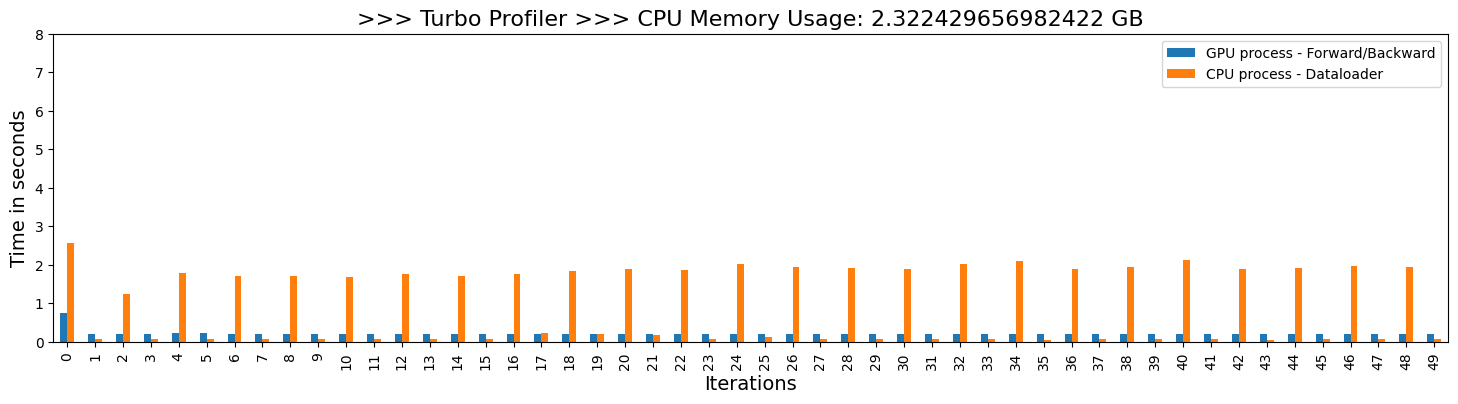

In [17]:
dataloader_trial = turbo_profiler(jobid,dataloader_info=True)

#### 4. Visualiser et comparer l'ensemble des résultats :

In [18]:
dataloader_trials.sort_values("loading_time").drop_duplicates() # trié par ordre croissant du LOADING_TIME

,jobid,num_workers,pin_memory,non_blocking,prefetch_factor,persistent_workers,drop_last,loading_time,1st_step_loading_time,CPU_memory_usage(GB)
0,622047,0,False,False,2,False,False,2.228604,2.447268,2.925117


<div class="alert alert-block alert-info">

## **Version optimisée** - Contrôle technique 

<div class="alert alert-block alert-warning">
    
**TODO** : relancer l'exécution sur 1 GPU et 100 itérations (`--test-nsteps 100`) sans profiling pour passer un nouveau contrôle technique, à comparer avec celui de référence.

</div>
</div>

### Soumission du job
<u>**Attention vous sollicitez les noeuds de calcul à ce moment-là**.</u>

Pour soumettre le job, veuillez basculer la cellule suivante du mode `Raw NBConvert` au mode `Code` (raccourci: touche `Y` avec la cellule sélectionnée)

In [19]:
command = f'./dlojz2_1.py -b {bs_optim} --image-size {image_size} --test --test-nsteps 100'

# définir ici les paramètres optimaux
command += ' --num-workers 0' 
command += ' --no-pin-memory'
command += ' --no-non-blocking'
command += ' --prefetch-factor 2'
command += ' --no-persistent-workers'
command += ' --no-drop-last'

n_gpu = 1
jobid = gpu_jobs_submitter(command, n_gpu, MODULE, name=name,
                    account=account, time_max='00:10:00', constraint="h100", qos="qos_gpu_h100-dev")
print(f'jobid = {jobid}')

batch job 0: 1 GPUs distributed on 1 nodes with 1 tasks / 1 gpus per node and 10 cpus per task
Submitted batch job 622210
jobid = ['622210']


Puis, rebasculer la cellule précédente en mode `Raw NBConvert`, afin d'eviter de relancer un job par erreur (raccourci: touche `R` avec la cellule sélectionnée).

In [20]:
display_slurm_queue(name)

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
            622210    gpu_p6 test_smi  ssos043  R       4:26      1 jzxh010

 Done!


>>> Turbo Profiler >>> Training complete in 250.890014 s


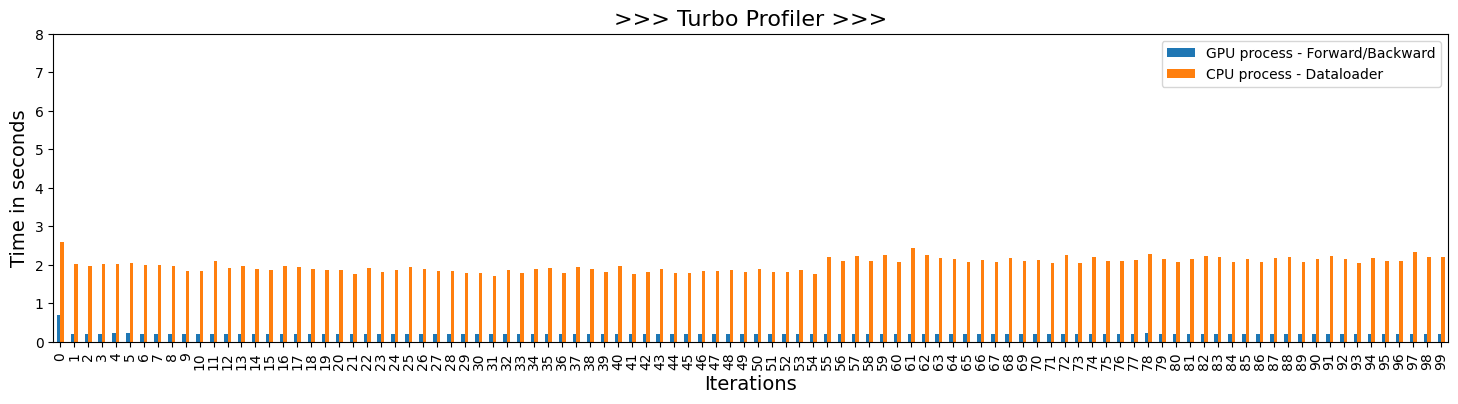

In [21]:
turbo_profiler(jobid)

In [22]:
controle_technique(jobid)

Train throughput: 229.66 images/second
GPU throughput: 2345.56 images/second
epoch time: 5580.07 seconds
-----------
training step time average (fwd/bkwd on GPU): 0.218284 sec (6.2%/93.8%) +/- 0.001161
loading step time average (IO + CPU to GPU transfer): 2.011068 sec +/- 0.161044


[Click here to display the log file](./slurm/log/test_smi@JZ_622210_1nodes_1tasks_2026-05-06_15.53.55.out)

<div class="alert alert-block alert-info">

## **OPTIONNEL** : Visualisation des traces profiler avec TensorBoard (version sous optimisée)

<div class="alert alert-block alert-warning">

**TODO** : relancer le job en **réactivant le profiler PyTorch** dans le script [dlojz2_1.py](./dlojz2_1.py) (revoir le TP1_4) afin de visualiser les traces sous TensorBoard, et les comparer avec la version optimisée étudiée dans le TP1.4.

</div>
</div>

### Soumission du job
<u>**Attention vous sollicitez les noeuds de calcul à ce moment-là**.</u>

Pour soumettre le job, veuillez basculer la cellule suivante du mode `Raw NBConvert` au mode `Code` (raccourci: touche `Y` avec la cellule sélectionnée)

In [23]:
command = f'./dlojz2_1.py -b {bs_optim} --image-size {image_size} --test --test-nsteps 8'
command += f' --num-workers 0 --no-persistent-workers --no-pin-memory --no-non-blocking'

n_gpu = 1
jobid = gpu_jobs_submitter(command, n_gpu, MODULE, name=name,
                    account=account, time_max='00:10:00', constraint="h100", qos="qos_gpu_h100-dev")
print(f'jobid = {jobid}')

batch job 0: 1 GPUs distributed on 1 nodes with 1 tasks / 1 gpus per node and 10 cpus per task
Submitted batch job 622286
jobid = ['622286']


Puis, rebasculer la cellule précédente en mode `Raw NBConvert`, afin d'eviter de relancer un job par erreur (raccourci: touche `R` avec la cellule sélectionnée).

In [24]:
display_slurm_queue(name)

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
            622286    gpu_p6 test_smi  ssos043  R       1:14      1 jzxh006

 Done!


<div class="alert alert-block alert-warning">

**TODO** : vérifier qu'une trace a bien été générée dans le répertoire `profiler/<name>_<jobid>_bs512_is224/` sous la forme d'un fichier `.json`:

</div>

In [25]:
!tree profiler/

profiler/ [error opening dir]

0 directories, 0 files


<div class="alert alert-block alert-warning">

**TODO** : visualiser cette trace grâce à l'application TensorBoard. 

</div>

<div class="alert alert-block alert-danger">

**IMPORTANT** : une fois le TP terminé, penser à quitter l'instance JupyterHub pour **libérer le GPU** ( *> Hub Control Panel > Cancel* ).

</div>

<img src="./images/stop.png" style="float: left; margin-right: 1em;"/>

----------------------

<div class="alert alert-block alert-success">

# TP2.2 : Distribution - Parallélisme de données

Voir la [documentation de l'IDRIS](http://www.idris.fr/docs/jean-zay/intelligence_artificielle/distribution_parallelisme/data-parallelism).

</div>
<div class="alert alert-block alert-warning">

**TODO** : dans le script [dlojz2_2.py](./dlojz2_2.py) :
* Importer les librairies liées à la distribution et au *Data Parallelism*.

* Configurer et initialiser l'environnement parallèle.

* Associer le bon GPU alloué au *process* actif.

* Basculer le modèle en mode *DistributedDataParallelism* pour qu'il soit dupliqué sur les différents GPU.

* Définir les *samplers* distribués `train_sampler` et `val_sampler` et les utiliser dans `train_loader` et `val_loader` respectivement. ***Attention***, le *shuffling* devra être délégué aux samplers.
    
* Au tout début de la boucle d'apprentissage, indiquer au *sampler* l'*epoch* en cours afin d'obtenir un *shuffling* différent à chaque *epoch*.

</div>

## Garage - Mise à niveau

In [26]:
image_size = 224
bs_optim = 512

## Soumission du job
<u>**Attention vous sollicitez les noeuds de calcul à ce moment-là**.</u>

Pour soumettre le job, veuillez basculer la cellule suivante du mode `Raw NBConvert` au mode `Code` (raccourci: touche `Y` avec la cellule sélectionnée)

In [56]:
command = f'./dlojz2_2.py -b {bs_optim} --image-size {image_size} --test --chkpt' 
n_gpu = 4
jobid = gpu_jobs_submitter(command, n_gpu, MODULE, name=name,
                    account=account, time_max='00:10:00', constraint="h100", qos="qos_gpu_h100-dev")
print(f'jobid = {jobid}')

batch job 0: 4 GPUs distributed on 1 nodes with 4 tasks / 4 gpus per node and 10 cpus per task
Submitted batch job 624120
jobid = ['624120']


Puis, rebasculer la cellule précédente en mode `Raw NBConvert`, afin d'eviter de relancer un job par erreur (raccourci: touche `R` avec la cellule sélectionnée).

In [57]:
display_slurm_queue(name)

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
            624120    gpu_p6 test_smi  ssos043  R       1:16      1 jzxh159

 Done!


<div class="alert alert-block alert-warning">

### **Quizz**
L'éxécution étant assez longue, un quizz vous attend : [Quizz TP2.2](https://www.deepmama.com/quizz/dlojz_quizz5.html)

</div>

In [58]:
controle_technique(jobid)

Train throughput: 7296.45 images/second
GPU throughput: 8962.25 images/second
epoch time: 175.71 seconds
-----------
training step time average (fwd/bkwd on GPU): 0.228514 sec (9.3%/91.6%) +/- 0.009922
loading step time average (IO + CPU to GPU transfer): 0.052170 sec +/- 0.133025


[Click here to display the log file](./slurm/log/test_smi@JZ_624120_1nodes_4tasks_2026-05-06_17.13.44.out)

<div class="alert alert-block alert-info">

### Communications
#### Découverte de comm_profiler
Pour ce TP, nous avons implémenté un profiler maison léger `comm_profiler` basé sur les traces de DEBUG de NCCL pour visualiser la quantité et le type de communications collectives échangées pendant une boucle d'apprentissage distribuée sur plusieurs GPU.

**À noter :** dans le script python [dlojz2_2.py](./dlojz2_2.py) les variables de trace de *DEBUG* *NCCL* sont configurées comme suit :

```python
if __name__ == '__main__':
    
    os.environ["NCCL_DEBUG"] = "INFO"
    os.environ["NCCL_DEBUG_SUBSYS"] = "INIT,COLL"
    # display info
    ...
```

</div>

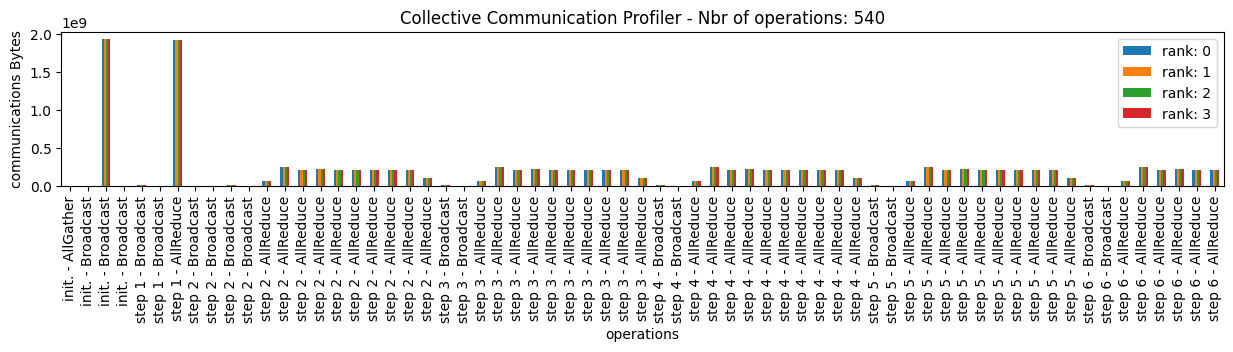

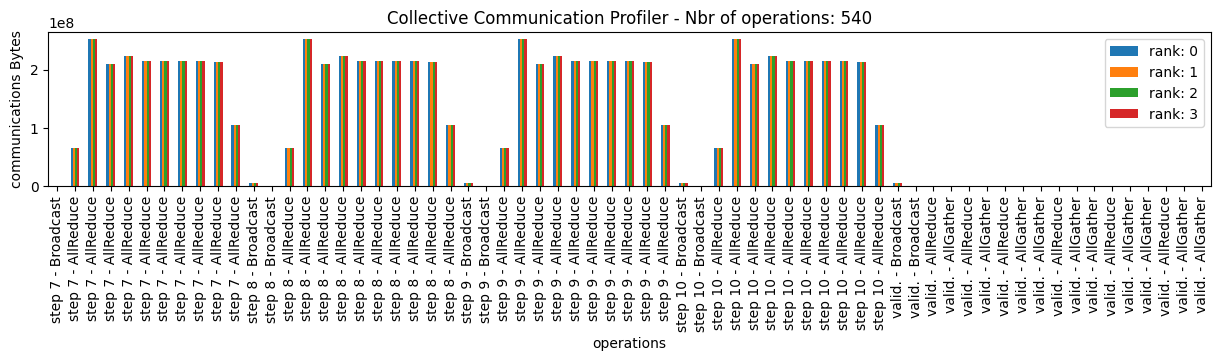

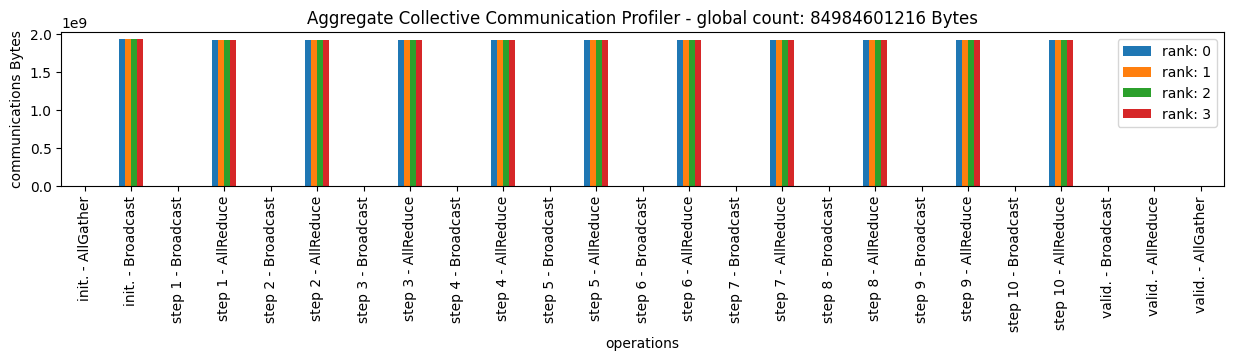

In [59]:
comm_profiler(jobid, n_display=65)

<div class="alert alert-block alert-info">

[Extrait de la documentation pytorch : ](https://pytorch.org/docs/stable/notes/ddp.html#internal-design)

> Each DDP process creates a local `Reducer`, which will take care of the gradients synchronization during the backward pass. To improve communication efficiency, the `Reducer` organizes parameter gradients into **buckets**, and reduces one bucket at a time. **Bucket size** can be configured by setting the bucket_cap_mb argument in DDP constructor. The mapping from parameter gradients to buckets is determined at the construction time, based on the bucket size limit and parameter sizes. 

</div>
<img src="./images/buckets1.png" style="float: left; margin-right: 1em;"/>

<div class="alert alert-block alert-info">

## Synchronized Metrics Communications 

D'après la [documentation de TorchMetrics](https://lightning.ai/docs/torchmetrics/stable/pages/overview.html):

> TorchMetrics is a Metrics API created for easy metric development and usage in PyTorch and PyTorch Lightning. It is rigorously tested for all edge cases and includes a growing list of common metric implementations.
>
> The metrics API provides `update()`, `compute()`, `reset()` functions to the user. The metric base class inherits `torch.nn.Module` which allows us to call `metric(...)` directly. The `forward()` method of the base Metric class serves the dual purpose of calling `update()` on its input and simultaneously returning the value of the metric over the provided input.
>
> These metrics work with **DDP** in PyTorch and PyTorch Lightning by default. When `.compute()` is called in distributed mode, the internal state of each metric is synced and reduced across each process, so that the logic present in `.compute()` is applied to state information from all processes.

Dans le test précedent, nous appliquions un `compute()` des *metrics* toutes les **100 itérations** pendant l'apprentissage et à la fin de chaque validation. Nous ne pouvions donc voir les communications de synchronisation des *metrics* qu'à la fin de la validation.

**Dans le test suivant,** nous appliquerons un `compute()` des *metrics* toutes les **8 itérations** d'apprentissage afin d'observer les communications des *metrics* pendant l'apprentissage.

</div>

### Soumission du job
<u>**Attention vous sollicitez les noeuds de calcul à ce moment-là**.</u>

Pour soumettre le job, veuillez basculer la cellule suivante du mode `Raw NBConvert` au mode `Code` (raccourci: touche `Y` avec la cellule sélectionnée)

In [60]:
command = f'./dlojz2_2.py -b {bs_optim} --image-size {image_size} --test --metric-step 8' 
n_gpu = 4
jobid_metric = gpu_jobs_submitter(command, n_gpu, MODULE, name=name,
                    account=account, time_max='00:10:00', constraint="h100", qos="qos_gpu_h100-dev")
print(f'jobid_metric  = {jobid_metric }')

batch job 0: 4 GPUs distributed on 1 nodes with 4 tasks / 4 gpus per node and 10 cpus per task
Submitted batch job 624236
jobid_metric  = ['624236']


Puis, rebasculer la cellule précédente en mode `Raw NBConvert`, afin d'eviter de relancer un job par erreur (raccourci: touche `R` avec la cellule sélectionnée).

In [61]:
display_slurm_queue(name)

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
            624236    gpu_p6 test_smi  ssos043  R       0:55      1 jzxh159

 Done!


In [62]:
controle_technique(jobid_metric)

Train throughput: 8432.53 images/second
GPU throughput: 8954.44 images/second
epoch time: 152.04 seconds
-----------
training step time average (fwd/bkwd on GPU): 0.228713 sec (9.3%/96.7%) +/- 0.067654
loading step time average (IO + CPU to GPU transfer): 0.014156 sec +/- 0.064332


[Click here to display the log file](./slurm/log/test_smi@JZ_624236_1nodes_4tasks_2026-05-06_17.17.41.out)

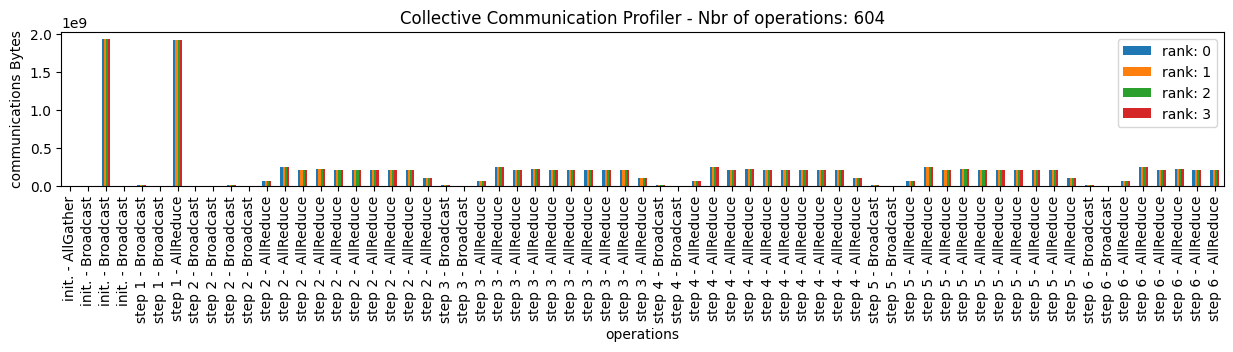

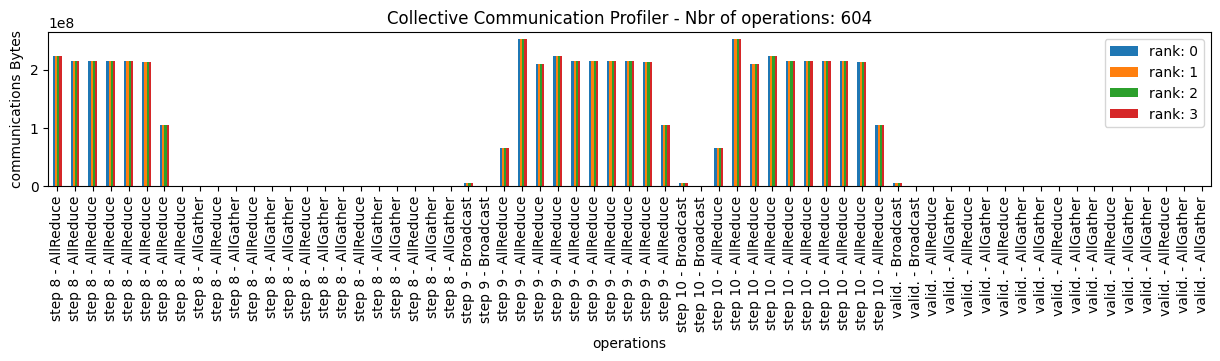

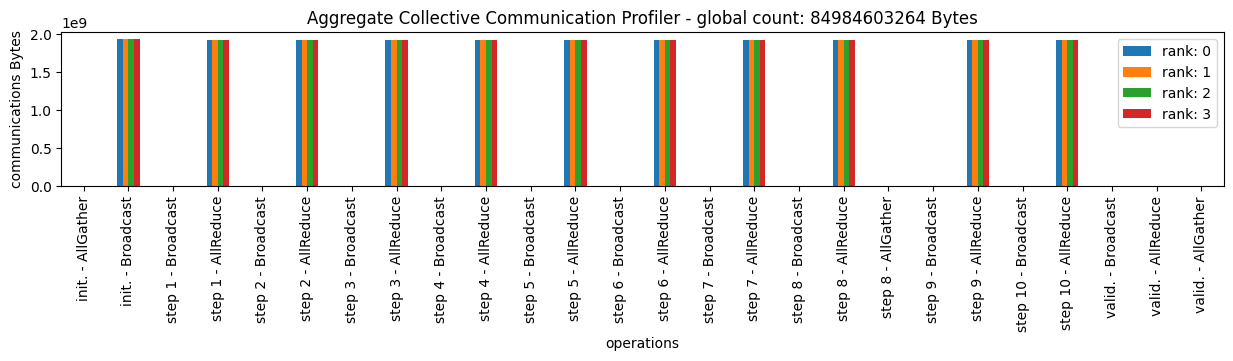

In [63]:
comm_profiler(jobid_metric, n_display=65)

### Zoom sur les communications

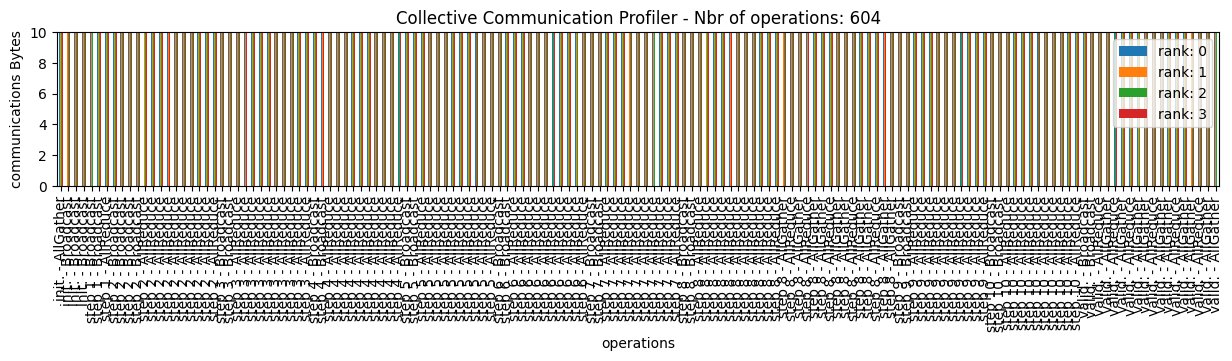

In [52]:
comm_profiler(jobid_metric, zoom=True)

### Valeurs des métriques avant et après les synchronisations

In [55]:
metric_compute_log(jobid_metric)

Step 8 - Before metric compute GPU0: loss: 7.0662455558776855, accuracy: 0.0009765625
Step 8 - Before metric compute GPU2: loss: 7.072941780090332, accuracy: 0.001953125
Step 8 - Before metric compute GPU1: loss: 7.09197473526001, accuracy: 0.001220703125
Step 8 - Before metric compute GPU3: loss: 7.072051048278809, accuracy: 0.00146484375
Step 8 - After metric compute GPU3: loss: 7.075803279876709, accuracy: 0.00140380859375
Step 8 - After metric compute GPU0: loss: 7.075803279876709, accuracy: 0.00140380859375
Step 8 - After metric compute GPU1: loss: 7.075803279876709, accuracy: 0.00140380859375
Step 8 - After metric compute GPU2: loss: 7.075803279876709, accuracy: 0.00140380859375
Step 16 - Before metric compute GPU2: loss: 7.006532192230225, accuracy: 0.000732421875
Step 16 - Before metric compute GPU3: loss: 7.018989562988281, accuracy: 0.001220703125
Step 16 - Before metric compute GPU1: loss: 7.015597343444824, accuracy: 0.001220703125
Step 16 - Before metric compute GPU0: loss

### DDP inter-noeud

Nous avons utilisé précédemment **4 GPU** sur le même nœud de calcul. Les bus de communication **intra-nœud** *NVLink* sont très rapide. **Le *scaling* est quasi parfait**.

Si nous utilisons **32 GPU** en *DDP* avec 4 nœuds de calcul et donc des communications sur le réseau d'**interconnexion des nœuds** nous obtenons le résultat suivant.

<div class="alert alert-block alert-danger">

**Ce test n'est pas faisable pendant le TP par chacun d'entre vous, pour des raisons évidentes d'accès aux ressources. Veuillez vous reporter au résultat fourni ici.**

</div>

<img src="./images/ddp32GPU.png" style="float: left; margin-right: 1em;"/>

<div class="alert alert-block alert-danger">

Assurez-vous que tout se passe bien avant de continuer
    
</div>
<img src="./images/cedez.png" style="float: left; margin-right: 1em;"/>

<div class="alert alert-block alert-info">

### BatchNorm Layer & SyncBatchNorm Layer
**Rappel** :

Pendant l'apprentissage, la couche normalise ses sorties en utilisant la moyenne et l'écart type du batch d'entrée.
Plus exactement, la couche retourne `(batch - mean(batch)) / (var(batch) + epsilon) * weight + bias` , avec :

* `epsilon`, une petite constante pour éviter la division par 0,
* `weight`, un facteur appris (entraîné) avec un calcul de gradient lors de la backpropagation et qui est initialisé à 1,
* `bias`, un facteur appris (entraîné) avec un calcul de gradient lors de la backpropagation et qui est initialisé à 0.

Pendant l'inférence ou la validation, la couche normalise ses sorties en utilisant en plus des `weight` et `bias` entraînés, les facteurs `running_mean` et `running_var` : `(batch - running_mean) / (running_var + epsilon) * weight + bias`.

`running_mean` et `running_var` sont des facteurs non entraînés, mais qui sont mis à jour à chaque itération de batch lors de l'apprentissage, selon la méthode suivante :

* `running_mean = running_mean * momentum + mean(batch) * (1 - momentum)`
* `running_var = running_var * momentum + var(batch) * (1 - momentum)`

</div>

In [ ]:
import torchvision.models as models
model = models.resnet152()

In [ ]:
BatchNorm_view(jobid, model)

<div class="alert alert-block alert-info">
    
### SyncBatchNorm layer
Voir la [documentation PyTorch](http://www.idris.fr/ia/syncbn.html#syncbn_en_pytorch).

</div>
<div class="alert alert-block alert-warning">

**TODO** : dans le script [dlojz2_2.py](./dlojz2_2.py) :
* Juste avant la bascule du modèle en mode *DistributedDataParallelism*, transformer les couches *BatchNorm* du modèle en couches *SyncBatchNorm*.

</div>

### Soumission du job
<u>**Attention vous sollicitez les noeuds de calcul à ce moment-là**.</u>

Pour soumettre le job, veuillez basculer la cellule suivante du mode `Raw NBConvert` au mode `Code` (raccourci: touche `Y` avec la cellule sélectionnée)

In [ ]:
command = f'./dlojz2_2.py -b {bs_optim} --image-size {image_size} --test --chkpt'
n_gpu = 4
jobid = gpu_jobs_submitter(command, n_gpu, MODULE, name=name,
                    account=account, time_max='00:10:00', constraint="h100", qos="qos_gpu_h100-dev")
print(f'jobid_sync = {jobid_sync}')

Puis, rebasculer la cellule précédente en mode `Raw NBConvert`, afin d'eviter de relancer un job par erreur (raccourci: touche `R` avec la cellule sélectionnée).

In [ ]:
display_slurm_queue(name)

In [ ]:
controle_technique(jobid_sync)

In [ ]:
BatchNorm_view(jobid + jobid_sync, model, labels=['BN Layer', 'SyncBN Layers'])

#### Communications

In [ ]:
comm_profiler(jobid_sync, n_display=100)

<div class="alert alert-block alert-danger">

Assurez-vous que tout se passe bien avant de continuer
    
</div>
<img src="./images/cedez.png" style="float: left; margin-right: 1em;"/>

<div class="alert alert-block alert-success">


# TP2_3 : DDP Advanced Parameters

<div class="alert alert-block alert-warning">

**TODO**: Voir la [documentation Pytorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.parallel.DistributedDataParallel.html#torch.nn.parallel.DistributedDataParallel) sur les paramètres de la classe `torch.nn.parallel.DistributedDataParallel`.

</div>

Les paramètres qui ne sont pas abordés dans la [documentation de l'IDRIS](http://www.idris.fr/jean-zay/gpu/jean-zay-gpu-torch-multi.html), ont peu d'intérêts, pour les petits modèles de la taille d'un Resnet-152.

Cependant dans certains cas particuliers, le paramètre `find_unused_parameters` devient nécessaire. Nous allons donc étudier ce paramètre dans ce TP.

</div>

<div class="alert alert-block alert-info">

## Find unused Parameters

> **find_unused_parameters (bool)** – Traverse the autograd graph from all tensors contained in the return value of the wrapped module’s forward function. Parameters that don’t receive gradients as part of this graph are preemptively marked as being ready to be reduced. In addition, parameters that may have been used in the wrapped module’s forward function but were not part of loss computation and thus would also not receive gradients are preemptively marked as ready to be reduced. (default: False)

</div>

<div class="alert alert-block alert-info">

### Stochastic Multi-head Classifier
<img src="./images/hydra.png" style="float: left; margin-right: 1em;" width=128 height=128/>  

Nous prenons ici, un modèle fantaisiste pour illustrer facilement un cas particulier de *unused parameters*.

A la fin d'un *Resnet-152* nous ajoutons plusieurs têtes de classifications. Lors de chaque *forward*, une seule tête sera choisi aléatoirement.

Nous sommes donc dans un cas où aléatoirement certaines couches, et donc certains **paramètres ne sont pas utilisés**. Observons ce qu'il se passe !

Dans le fichier [dlojz2_3_1.py](./dlojz2_3_1.py), on initialise le modèle de la manière suivante, en utilisant le fichier [custom_models.py](./custom_models.py):

```python
import torchvision.models as models 
from custom_models import add_conditional_heads

model = models.resnet152()
model = add_conditional_heads(model, n_heads=3)
```

</div>

### Soumission du job avec `find_unused_parameters=False`.
<u>**Attention vous sollicitez les noeuds de calcul à ce moment-là**.</u>

Pour soumettre le job, veuillez basculer la cellule suivante du mode `Raw NBConvert` au mode `Code` (raccourci: touche `Y` avec la cellule sélectionnée)

In [ ]:
command = f'./dlojz2_3_1.py -b {bs_optim} --image-size {image_size} --test'
n_gpu = 4
jobid = gpu_jobs_submitter(command, n_gpu, MODULE, name=name,
                    account=account, time_max='00:10:00', constraint="h100", qos="qos_gpu_h100-dev")
print(f'jobid = {jobid}')

Puis, rebasculer la cellule précédente en mode `Raw NBConvert`, afin d'eviter de relancer un job par erreur (raccourci: touche `R` avec la cellule sélectionnée).

In [ ]:
display_slurm_queue(name)

In [ ]:
controle_technique(jobid)

<div class="alert alert-block alert-warning">

**TODO** : Aller lire le *error log* pour interpréter l'erreur remontée.

</div>

### Soumission du job avec `find_unused_parameters=True`.
<u>**Attention vous sollicitez les noeuds de calcul à ce moment-là**.</u>

Pour soumettre le job, veuillez basculer la cellule suivante du mode `Raw NBConvert` au mode `Code` (raccourci: touche `Y` avec la cellule sélectionnée)

In [ ]:
command = f'./dlojz2_3_1.py -b {bs_optim} --image-size {image_size} --test --find-unused-parameters'
n_gpu = 4
jobid = gpu_jobs_submitter(command, n_gpu, MODULE, name=name,
                    account=account, time_max='00:10:00', constraint="h100", qos="qos_gpu_h100-dev")
print(f'jobid = {jobid}')

Puis, rebasculer la cellule précédente en mode `Raw NBConvert`, afin d'eviter de relancer un job par erreur (raccourci: touche `R` avec la cellule sélectionnée).

In [ ]:
display_slurm_queue(name)

In [ ]:
controle_technique(jobid)

<div class="alert alert-block alert-info">

### Stochastic Depth
<img src="./images/Stochastic-Depth.png" style="float: left; margin-right: 1em;" width=640/>  

Le *Stochastic Depth* est une technique de *regularization* lors de l'apprentissage qui *drop* aléatoirement des *layers* entiers avec une probabilité de plus en plus forte selon la profondeur de la couche.

Nous sommes donc dans un nouveau cas de **paramètres non utilisés** aléatoirement, que nous allons testé de la même manière que précedemment.

Dans le fichier [dlojz2_3_2.py](./dlojz2_3_2.py), on initialise le modèle de la manière suivante, en utilisant le fichier [custom_models.py](./custom_models.py):

<br></br>
```python
from custom_models import resnet152_with_stochastic_depth

model = resnet152_with_stochastic_depth()
```

</div>

### Soumission du job avec `find_unused_parameters=False`.
<u>**Attention vous sollicitez les noeuds de calcul à ce moment-là**.</u>

Pour soumettre le job, veuillez basculer la cellule suivante du mode `Raw NBConvert` au mode `Code` (raccourci: touche `Y` avec la cellule sélectionnée)

In [ ]:
command = f'./dlojz2_3_2.py -b {bs_optim} --image-size {image_size} --test'
n_gpu = 4
jobid = gpu_jobs_submitter(command, n_gpu, MODULE, name=name,
                    account=account, time_max='00:10:00', constraint="h100", qos="qos_gpu_h100-dev")
print(f'jobid = {jobid}')

Puis, rebasculer la cellule précédente en mode `Raw NBConvert`, afin d'eviter de relancer un job par erreur (raccourci: touche `R` avec la cellule sélectionnée).

In [ ]:
display_slurm_queue(name)

In [ ]:
controle_technique(jobid)

<div class="alert alert-block alert-info">

**Remarque**: Ici, on utilise des *masks* pour *drop* certaines *layers*. Tous les gradients — ainsi que les activations — sont donc bien calculés, puis remis à zéro lorsqu’ils sont masqués. Le graphe de calcul reste complet et identique pour chaque passage, ce qui évite tout problème de synchronisation des gradients entre processus.
Dans ce contexte, le paramètre `find_unused_parameters` de **DDP** n’est pas nécessaire.

En revanche, pour des architectures réellement dynamiques, comme les modèles à **routage conditionnel** (*Mixture-of-Experts*, *Switch Transformers*) ou les **classifieurs multi-head** activant des branches différentes selon l’entrée, l’approche par masquage devient coûteuse et peu réaliste.
Dans ces cas, il est préférable d’activer `find_unused_parameters=True`, afin de permettre à DDP de gérer automatiquement les paramètres non utilisés lors du passage avant-arrière. 

</div>

<div class="alert alert-block alert-danger">

Arrêtez-vous ici! Une présentation vous attend avant le prochain TP.

</div>

<img src="./images/stop.png" style="float: left; margin-right: 1em;"/>